# 03. TSTR: GARCH на синтетических данных, тест на реальных

**Q1.** Если убрать реальный train и заменить его синтетическим — что станет с прогнозом GARCH?

Протокол **Train on Synthetic, Test on Real (TSTR)**:

1. Обучаем GAN (TimeGAN или CTGAN) на real train.
2. Семплируем синтетический ряд той же длины (2515 точек).
3. Обучаем GARCH(1,1)-t **только на синтетике**, фиксируем параметры.
4. Делаем walk-forward на real test (2020–2024) и сравниваем с B1.

Прогрев state σ² при walk-forward делаем на real train (нам важно проверить только «след обучения», а не качество прогрева).

In [1]:
import sys, json
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
ART = ROOT / "artifacts"

params_real = json.loads((ART / "garch_params_real.json").read_text(encoding="utf-8"))
params_tg   = json.loads((ART / "garch_params_synth_timegan.json").read_text(encoding="utf-8"))
params_ct   = json.loads((ART / "garch_params_synth_ctgan.json").read_text(encoding="utf-8"))

p_table = pd.DataFrame({
    "B1 (real)":   params_real,
    "B2-TimeGAN":  params_tg,
    "B2-CTGAN":    params_ct,
}).T[["mu","omega","alpha","beta","nu","dist"]]
p_table["alpha+beta"] = p_table["alpha"] + p_table["beta"]
p_table.round(5)

,mu,omega,alpha,beta,nu,dist,alpha+beta
B1 (real),0.086791,0.025294,0.175878,0.812557,4.873854,t,0.988435
B2-TimeGAN,-0.028801,0.693481,0.202546,0.0,499.980791,t,0.202546
B2-CTGAN,0.050303,1.182161,0.0,0.441988,3.349596,t,0.441988


In [2]:
summary = pd.read_csv(ART / "metrics_summary.csv")
mask = summary["branch"].isin(["B1_real", "B2_timegan", "B2_ctgan"])
cols = ["branch","RMSE_abs_r","MAE_abs_r","QLIKE","MZ_a","MZ_b","MZ_R2",
        "VaR5_violations","VaR5_rate","VaR5_kupiec_p",
        "VaR1_violations","VaR1_rate","VaR1_kupiec_p"]
summary.loc[mask, cols].set_index("branch").round(4)

,RMSE_abs_r,MAE_abs_r,QLIKE,MZ_a,MZ_b,MZ_R2,VaR5_violations,VaR5_rate,VaR5_kupiec_p,VaR1_violations,VaR1_rate,VaR1_kupiec_p
branch,,,,,,,,,,,,
B1_real,0.8867,0.6334,1.0898,1.645000e-01,9.002000e-01,0.3042,99,0.0787,0.0000,20,0.0159,0.0528
B2_timegan,0.9378,0.6444,1.4460,-7.465000e-01,2.419200e+00,0.2401,91,0.0723,0.0006,44,0.0350,0.0000
B2_ctgan,1.1682,0.9231,1.6098,-1.870464e+12,8.829097e+11,0.3265,57,0.0453,0.4383,12,0.0095,0.8685


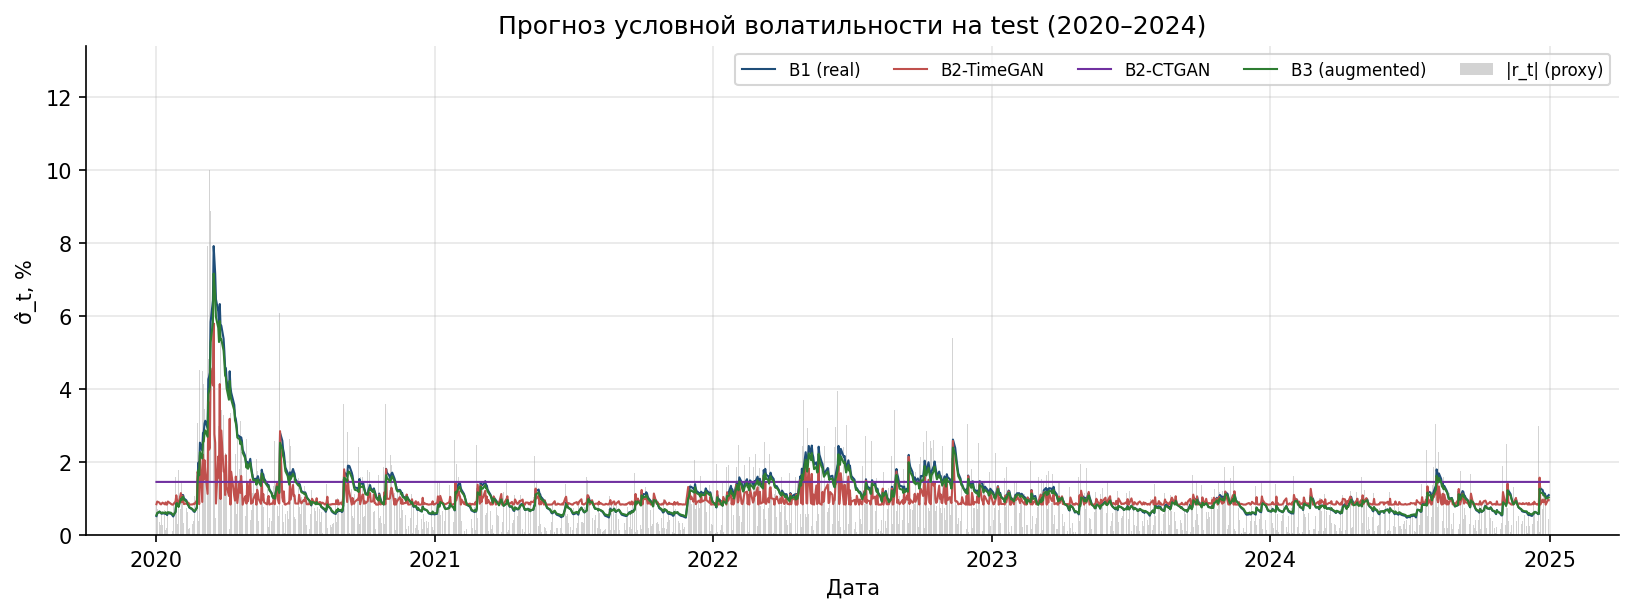

In [3]:
from IPython.display import Image
Image(filename="artifacts/figures/05_volatility_forecasts.png")

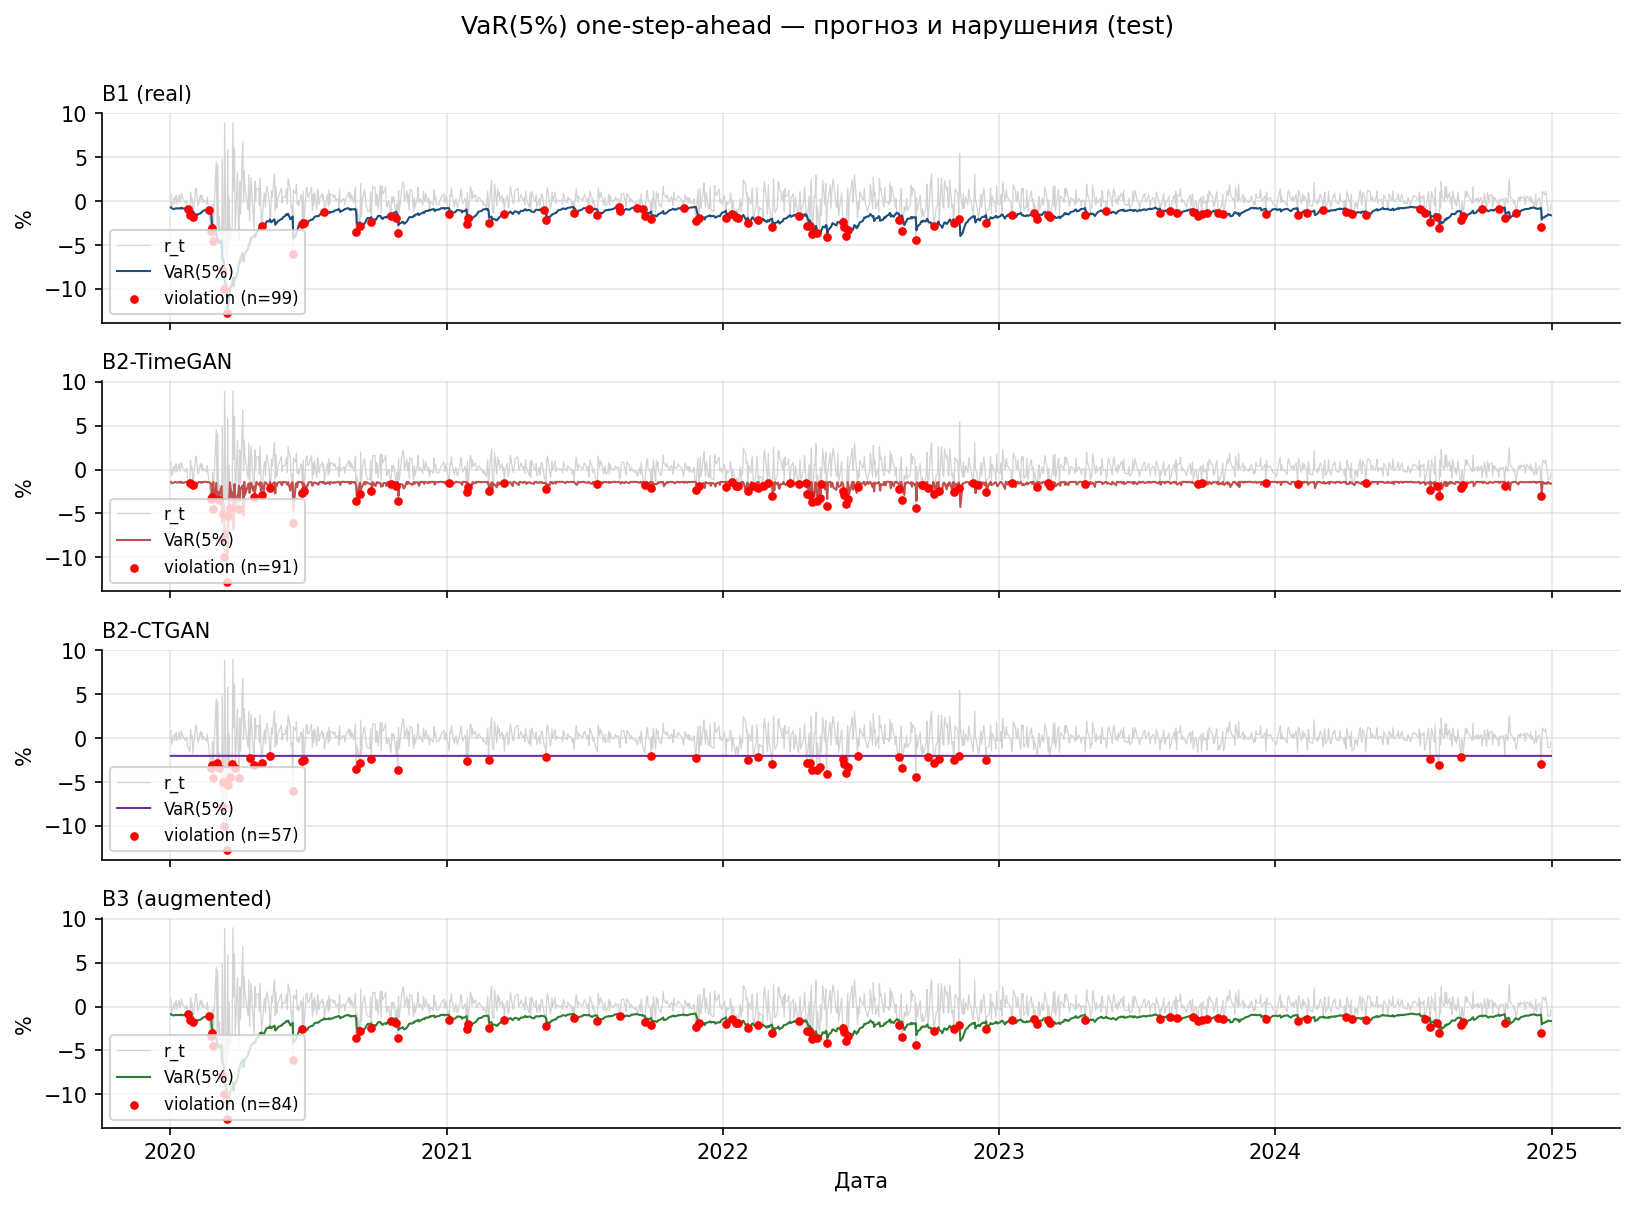

In [4]:
Image(filename="artifacts/figures/06_var_violations_5.png")

**Что говорит TSTR-сравнение:**

* **B2-TimeGAN:** GARCH «увидел» в синтетике короткую реакцию на шок (α ≈ 0.20), но не увидел персистентности (β ≈ 0!). Это прямое следствие того, что TimeGAN сжал хвосты и не воспроизвёл ACF |r| на средних лагах — модели не из чего «строить» β. Качество прогноза по RMSE и QLIKE заметно хуже B1, **VaR(1%) фактически не работает (3.5% нарушений vs ожидаемые 1%)**.
* **B2-CTGAN:** GARCH вообще не нашёл шок-отклика (α ≈ 0), persistence заперт через β. Параметры численно нестабильны (MZ-коэффициенты разлетаются). При этом доля нарушений VaR случайно близка к номинальной — но это не «правильный риск», а просто **слишком широкий VaR** (большая ω даёт почти константно высокий σ). RMSE — самый плохой из четырёх веток.
* **Резюме Q1:** даже специализированный для рядов TimeGAN при чистом TSTR-протоколе **ухудшает прогноз GARCH**: ключевая компонента β теряется, оценка хвостового риска становится нерабочей. CTGAN ещё хуже. Заменять реальные данные синтетикой при обучении волатильностной модели **нельзя**, по крайней мере без дополнительных усилий по сохранению ACF на большем числе лагов.